<a href="https://colab.research.google.com/github/AylinSahin/MagicBathyNet/blob/main/depth_anything_v2_real_finetuning_bathymetry_v2_revised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Depth Anything V2 Real Fine-tuning for UAV-based Shallow Water Bathymetry — revised v2

This notebook is a **clean, verification-first Depth Anything V2 training notebook** for UAV/orthophoto-based shallow-water bathymetry.

Revision notes:
- MagicBathyNet aerial RGB/depth folder structure is handled explicitly and auto-detected where possible.
- MagicBathyNet negative depth convention is handled with a water mask.
- `TRAIN_MODE="partial"` uses encoder-aware last-block selection, not fixed ViT-L block IDs.
- A100 mixed precision uses `bfloat16`.
- GeoTIFF edge tiles use edge padding, not zero padding.
- The current default architecture adapts the **final DA V2 depth-like output** with a trainable bathymetry head. This is a valid fast partial fine-tuning experiment if DA V2 gradients/weight updates are verified, but it is **not equivalent to a full intermediate-feature DPT head**.


## 1. Setup and environment check

In [2]:
# ============================================================
# 1. Setup and environment check
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import sys
import subprocess
from pathlib import Path

def run(cmd):
    print(">>", cmd)
    subprocess.run(cmd, shell=True, check=True)

run("pip -q install rasterio pyproj openpyxl scikit-learn tqdm einops")

DA_REPO = Path("/content/Depth-Anything-V2")
if not DA_REPO.exists():
    run("git clone https://github.com/DepthAnything/Depth-Anything-V2.git /content/Depth-Anything-V2")
else:
    print("Depth Anything V2 repo already exists:", DA_REPO)

sys.path.insert(0, str(DA_REPO))

import random
import numpy as np
import pandas as pd
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    print("Total VRAM [GB]:", round(props.total_memory / 1024**3, 2))
    print("CUDA version:", torch.version.cuda)
else:
    print("CUDA unavailable. This notebook is intended for A100/L4/H100 GPU.")

torch.backends.cudnn.benchmark = True

USE_AMP = torch.cuda.is_available()
AMP_DTYPE = torch.bfloat16 if torch.cuda.is_available() else torch.float32
print("USE_AMP:", USE_AMP, "AMP_DTYPE:", AMP_DTYPE)


Mounted at /content/drive
>> pip -q install rasterio pyproj openpyxl scikit-learn tqdm einops
>> git clone https://github.com/DepthAnything/Depth-Anything-V2.git /content/Depth-Anything-V2
DEVICE: cuda
GPU: NVIDIA A100-SXM4-80GB
Total VRAM [GB]: 79.25
CUDA version: 12.8
USE_AMP: True AMP_DTYPE: torch.bfloat16


In [3]:
!mkdir -p /content/Depth-Anything-V2/checkpoints
!cp -n /content/drive/MyDrive/Colab_Notebooks/depth_anything_v2_metric_hypersim_vitl.pth /content/Depth-Anything-V2/checkpoints
!cp -n /content/drive/MyDrive/Colab_Notebooks/depth_anything_v2_metric_vkitti_vitl.pth /content/Depth-Anything-V2/checkpoints
!cp -n /content/drive/MyDrive/Colab_Notebooks/depth_anything_v2_vitl.pth /content/Depth-Anything-V2/checkpoints
!cp -n /content/drive/MyDrive/Colab_Notebooks/lake_area.tif /content/Depth-Anything-V2/
!cp -n /content/drive/MyDrive/Colab_Notebooks/lake_calculation_area.tif /content/Depth-Anything-V2/

print("✅ Dosya kurulumu tamamlandı.")

✅ Dosya kurulumu tamamlandı.


## 2. Path config

Edit this section before running the rest of the notebook.


In [4]:
# ============================================================
# 2. Path config
# ============================================================

from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/MagicBathyNet_DA_V2_real_finetuning_v2")
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)

DA_REPO = Path("/content/Depth-Anything-V2")

# Choose encoder: "vits", "vitb", "vitl".
# Recommendation for first verified run on A100: "vitb".
# Switch to "vitl" only after all sanity checks pass.
DA_ENCODER = "vitb"

DA_PRETRAINED_CKPT = Path(f"/content/drive/MyDrive/DepthAnythingV2/checkpoints/depth_anything_v2_{DA_ENCODER}.pth")

# -------------------------------------------------------------------
# MagicBathyNet paths
# -------------------------------------------------------------------
DATA_ROOT = Path("/content/drive/MyDrive/MagicBathyNet")

# Expected MagicBathyNet structure is commonly:
#   DATA_ROOT / "puck_lagoon/img/aerial"
#   DATA_ROOT / "puck_lagoon/depth/aerial"
# but we allow manual override.
RGB_DIR = DATA_ROOT / "puck_lagoon/img/aerial"
LABEL_DIR = DATA_ROOT / "puck_lagoon/depth/aerial"

# Fallback candidates if your Drive folder differs.
RGB_CANDIDATES = [
    RGB_DIR,
    DATA_ROOT / "img/aerial",
    DATA_ROOT / "rgb",
    DATA_ROOT / "images",
]
LABEL_CANDIDATES = [
    LABEL_DIR,
    DATA_ROOT / "depth/aerial",
    DATA_ROOT / "depth",
    DATA_ROOT / "labels",
]

def first_existing(candidates, default):
    for p in candidates:
        if Path(p).exists():
            return Path(p)
    return Path(default)

RGB_DIR = first_existing(RGB_CANDIDATES, RGB_DIR)
LABEL_DIR = first_existing(LABEL_CANDIDATES, LABEL_DIR)

# Your Antarctic UAV orthophoto and GPR validation data
ORTHO_TIF = Path("/content/drive/MyDrive/MagicBathyNet/lake_calculation_area.tif")
GPR_XLSX = Path("/content/drive/MyDrive/MagicBathyNet/GPR_Depth_Analysis.xlsx")

OUT_DIR = PROJECT_ROOT / "outputs"
CKPT_DIR = PROJECT_ROOT / "checkpoints"
FIG_DIR = PROJECT_ROOT / "figures"
TABLE_DIR = PROJECT_ROOT / "tables"
DEBUG_DIR = PROJECT_ROOT / "debug_outputs"

for p in [OUT_DIR, CKPT_DIR, FIG_DIR, TABLE_DIR, DEBUG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DA_PRETRAINED_CKPT exists:", DA_PRETRAINED_CKPT.exists(), DA_PRETRAINED_CKPT)
print("DATA_ROOT exists:", DATA_ROOT.exists(), DATA_ROOT)
print("RGB_DIR exists:", RGB_DIR.exists(), RGB_DIR)
print("LABEL_DIR exists:", LABEL_DIR.exists(), LABEL_DIR)
print("ORTHO_TIF exists:", ORTHO_TIF.exists(), ORTHO_TIF)
print("GPR_XLSX exists:", GPR_XLSX.exists(), GPR_XLSX)

if not RGB_DIR.exists() or not LABEL_DIR.exists():
    raise FileNotFoundError(
        "RGB_DIR or LABEL_DIR does not exist. Edit the path config cell to match your MagicBathyNet folder structure."
    )


PROJECT_ROOT: /content/drive/MyDrive/MagicBathyNet_DA_V2_real_finetuning_v2
DA_PRETRAINED_CKPT exists: True /content/drive/MyDrive/DepthAnythingV2/checkpoints/depth_anything_v2_vitb.pth
DATA_ROOT exists: True /content/drive/MyDrive/MagicBathyNet
RGB_DIR exists: True /content/drive/MyDrive/MagicBathyNet/puck_lagoon/img/aerial
LABEL_DIR exists: True /content/drive/MyDrive/MagicBathyNet/puck_lagoon/depth/aerial
ORTHO_TIF exists: False /content/drive/MyDrive/MagicBathyNet/lake_calculation_area.tif
GPR_XLSX exists: False /content/drive/MyDrive/MagicBathyNet/GPR_Depth_Analysis.xlsx


## 3. Preprocessing and label conventions

In [5]:
# ============================================================
# 3. Preprocessing and label conventions
# ============================================================

import numpy as np
import cv2
import rasterio
import torch
import torch.nn.functional as F

DA_INPUT_SIZE = 518

RGB_NORM_MIN = np.array([0.0, 0.0, 0.0], dtype=np.float32)
RGB_NORM_MAX = np.array([255.0, 255.0, 255.0], dtype=np.float32)

# MagicBathyNet Puck Lagoon convention often stores bathymetric depth as negative elevation values.
# With NORM_PARAM_DEPTH = -11, depth labels are typically abs(depth_raw) / abs(-11).
NORM_PARAM_DEPTH = -11.0

# Set this to True for MagicBathyNet raw depth rasters in meters.
LABELS_ARE_METERS = True

# If True, negative raw depths mean valid water depth and are converted with abs(depth).
# If your depth rasters are already positive depth values, set this to False.
DEPTH_NEGATIVE_IS_WATER = True

PREPROCESSING_CONFIG = {
    "rgb_norm_min": RGB_NORM_MIN.tolist(),
    "rgb_norm_max": RGB_NORM_MAX.tolist(),
    "da_input_size": DA_INPUT_SIZE,
    "norm_param_depth": NORM_PARAM_DEPTH,
    "labels_are_meters": LABELS_ARE_METERS,
    "depth_negative_is_water": DEPTH_NEGATIVE_IS_WATER,
    "label_convention": "valid_water_depth_abs_m_div_abs_norm_param_depth"
}

def preprocess_rgb(rgb, norm_min=RGB_NORM_MIN, norm_max=RGB_NORM_MAX, resize_to=None):
    """
    Common preprocessing for both training and GeoTIFF inference.

    Input: HWC RGB array. RGBA alpha must already be excluded.
    Output: float32 HWC in [0,1].
    """
    rgb = np.asarray(rgb)

    if rgb.ndim != 3:
        raise ValueError(f"Expected HWC RGB array, got shape={rgb.shape}")

    if rgb.shape[2] < 3:
        raise ValueError(f"Expected at least 3 channels, got shape={rgb.shape}")

    rgb = rgb[:, :, :3].astype(np.float32)

    finite = np.isfinite(rgb)
    mx = float(np.nanmax(rgb[finite])) if finite.any() else 0.0

    # If already scaled to [0,1], keep as is.
    if mx <= 1.5 and np.nanmin(rgb) >= -0.1:
        out = rgb.copy()
    else:
        norm_min = norm_min.reshape(1, 1, 3).astype(np.float32)
        norm_max = norm_max.reshape(1, 1, 3).astype(np.float32)
        out = (rgb - norm_min) / (norm_max - norm_min + 1e-8)

    out = np.clip(out, 0.0, 1.0).astype(np.float32)

    if resize_to is not None:
        out = cv2.resize(out, (resize_to, resize_to), interpolation=cv2.INTER_LINEAR)

    return out

def normalize_for_depth_anything(x01):
    """
    x01: torch tensor [B,3,H,W] in [0,1], RGB.
    DA V2 official transform uses ImageNet-style normalization.
    """
    mean = torch.tensor([0.485, 0.456, 0.406], device=x01.device, dtype=x01.dtype).view(1,3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225], device=x01.device, dtype=x01.dtype).view(1,3,1,1)
    return (x01 - mean) / std

def make_depth_label_and_mask(depth_raw, norm_param_depth=NORM_PARAM_DEPTH, negative_is_water=DEPTH_NEGATIVE_IS_WATER):
    """
    Convert raw MagicBathyNet depth raster to positive normalized depth label and water mask.

    If negative_is_water=True:
        valid water pixels are finite and depth_raw < 0.
        label_norm = abs(depth_raw) / abs(norm_param_depth).

    If negative_is_water=False:
        valid water pixels are finite and depth_raw > 0.
        label_norm = depth_raw / abs(norm_param_depth).

    Returns:
        label_norm float32 HxW, invalid pixels = 0
        water_mask float32 HxW, valid water = 1
    """
    depth_raw = np.asarray(depth_raw, dtype=np.float32)
    finite = np.isfinite(depth_raw)

    if negative_is_water:
        water = finite & (depth_raw < 0)
        depth_positive_m = np.zeros_like(depth_raw, dtype=np.float32)
        depth_positive_m[water] = np.abs(depth_raw[water])
    else:
        water = finite & (depth_raw > 0)
        depth_positive_m = np.zeros_like(depth_raw, dtype=np.float32)
        depth_positive_m[water] = depth_raw[water]

    label_norm = np.zeros_like(depth_raw, dtype=np.float32)
    label_norm[water] = depth_positive_m[water] / (abs(float(norm_param_depth)) + 1e-8)
    label_norm = np.clip(label_norm, 0.0, 1.5).astype(np.float32)

    mask = water.astype(np.float32)
    return label_norm, mask

def depth_to_label_norm(depth_m, norm_param_depth=NORM_PARAM_DEPTH):
    """For positive physical depth values in meters."""
    return np.asarray(depth_m, dtype=np.float32) / abs(float(norm_param_depth))

def label_norm_to_depth_m(label_norm, norm_param_depth=NORM_PARAM_DEPTH):
    return np.asarray(label_norm, dtype=np.float32) * abs(float(norm_param_depth))

print("Preprocessing config:")
print(PREPROCESSING_CONFIG)
print("NOTE: raw model output is an index/normalized output unless explicitly converted or GPR-calibrated.")


Preprocessing config:
{'rgb_norm_min': [0.0, 0.0, 0.0], 'rgb_norm_max': [255.0, 255.0, 255.0], 'da_input_size': 518, 'norm_param_depth': -11.0, 'labels_are_meters': True, 'depth_negative_is_water': True, 'label_convention': 'valid_water_depth_abs_m_div_abs_norm_param_depth'}
NOTE: raw model output is an index/normalized output unless explicitly converted or GPR-calibrated.


## 4. Dataset and DataLoader

In [6]:
# ============================================================
# 4. Dataset and DataLoader
# ============================================================

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from pathlib import Path
import rasterio
import numpy as np
import cv2
import re
import torch

IMAGE_EXTS = [".tif", ".tiff", ".png", ".jpg", ".jpeg"]

def extract_numeric_id(stem):
    """
    Match img_123.tif with depth_123.tif.
    If no numeric suffix exists, fall back to raw stem.
    """
    m = re.search(r"(\d+)$", stem)
    return m.group(1) if m else stem

def discover_pairs(rgb_dir, label_dir):
    rgb_dir = Path(rgb_dir)
    label_dir = Path(label_dir)

    rgb_files = []
    for ext in IMAGE_EXTS:
        rgb_files.extend(sorted(rgb_dir.glob(f"*{ext}")))

    label_files = []
    for ext in IMAGE_EXTS:
        label_files.extend(sorted(label_dir.glob(f"*{ext}")))

    label_by_key = {extract_numeric_id(p.stem): p for p in label_files}

    pairs = []
    missing = []
    for r in rgb_files:
        key = extract_numeric_id(r.stem)
        if key in label_by_key:
            pairs.append({"id": key, "rgb": r, "label": label_by_key[key]})
        else:
            missing.append(r.stem)

    print("RGB files:", len(rgb_files))
    print("Label files:", len(label_files))
    print("Matched pairs:", len(pairs))
    print("Missing labels:", len(missing))
    print("Example pairs:")
    for p in pairs[:3]:
        print(" ", p["id"], "|", p["rgb"].name, "<->", p["label"].name)

    if len(pairs) == 0:
        raise RuntimeError(
            "No matched RGB-label pairs found. Check RGB_DIR/LABEL_DIR and file naming. "
            "Expected names like img_0.tif and depth_0.tif."
        )

    return pairs

def read_rgb_file(path):
    path = Path(path)
    if path.suffix.lower() in [".tif", ".tiff"]:
        with rasterio.open(path) as src:
            arr = src.read()
        arr = np.transpose(arr, (1,2,0))
        return arr[:, :, :3]
    else:
        img = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
        if img is None:
            raise FileNotFoundError(path)
        if img.ndim == 2:
            img = np.stack([img, img, img], axis=-1)
        if img.shape[2] >= 3:
            img = cv2.cvtColor(img[:, :, :3], cv2.COLOR_BGR2RGB)
        return img

def read_label_file(path):
    path = Path(path)
    if path.suffix.lower() in [".tif", ".tiff"]:
        with rasterio.open(path) as src:
            arr = src.read(1).astype(np.float32)
            nodata = src.nodata
        if nodata is not None:
            arr[arr == nodata] = np.nan
        return arr
    else:
        arr = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
        if arr is None:
            raise FileNotFoundError(path)
        if arr.ndim == 3:
            arr = arr[:, :, 0]
        return arr.astype(np.float32)

class BathyPairDataset(Dataset):
    def __init__(self, pairs, input_size=DA_INPUT_SIZE, norm_param_depth=NORM_PARAM_DEPTH):
        self.pairs = list(pairs)
        self.input_size = input_size
        self.norm_param_depth = norm_param_depth

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        item = self.pairs[idx]
        rgb = read_rgb_file(item["rgb"])
        depth_raw = read_label_file(item["label"])

        rgb_p = preprocess_rgb(rgb, resize_to=self.input_size)

        depth_rs = cv2.resize(
            depth_raw.astype(np.float32),
            (self.input_size, self.input_size),
            interpolation=cv2.INTER_NEAREST
        )

        if LABELS_ARE_METERS:
            y_norm, water_mask = make_depth_label_and_mask(
                depth_rs,
                norm_param_depth=self.norm_param_depth,
                negative_is_water=DEPTH_NEGATIVE_IS_WATER
            )
        else:
            # If labels are already normalized, valid pixels are finite and >0.
            finite = np.isfinite(depth_rs)
            water = finite & (depth_rs > 0)
            y_norm = np.zeros_like(depth_rs, dtype=np.float32)
            y_norm[water] = depth_rs[water].astype(np.float32)
            water_mask = water.astype(np.float32)

        x = torch.from_numpy(np.transpose(rgb_p, (2,0,1))).float()
        y = torch.from_numpy(y_norm).unsqueeze(0).float()
        mask = torch.from_numpy(water_mask).unsqueeze(0).float()

        return {"x": x, "y": y, "mask": mask, "id": item["id"]}

pairs = discover_pairs(RGB_DIR, LABEL_DIR)

# ============================================================
# Filter pairs with too few valid water pixels
# ============================================================

MIN_VALID_WATER_FRACTION = 0.01

def estimate_water_fraction_from_label(label_path):
    import rasterio
    import numpy as np

    with rasterio.open(label_path) as src:
        arr = src.read(1).astype(np.float32)
        nodata = src.nodata

    valid = np.isfinite(arr)

    if nodata is not None:
        valid &= (arr != nodata)

    if DEPTH_NEGATIVE_IS_WATER:
        water = valid & (arr < 0)
    else:
        water = valid & (arr > 0)

    return float(water.mean())

def filter_pairs_by_water_fraction(pairs, min_fraction=0.01):
    kept = []
    dropped = []

    for p in pairs:
        frac = estimate_water_fraction_from_label(p["label"])

        p2 = dict(p)
        p2["water_fraction"] = frac

        if frac >= min_fraction:
            kept.append(p2)
        else:
            dropped.append(p2)

    return kept, dropped

pairs_filtered, pairs_dropped = filter_pairs_by_water_fraction(
    pairs,
    min_fraction=MIN_VALID_WATER_FRACTION
)

print("Original pairs:", len(pairs))
print("Kept pairs:", len(pairs_filtered))
print("Dropped pairs:", len(pairs_dropped))
print("Dropped fraction:", len(pairs_dropped) / max(len(pairs), 1))

if len(pairs_dropped) > 0:
    print("Example dropped:")
    for p in pairs_dropped[:5]:
        print(
            p["rgb"].name,
            "<->",
            p["label"].name,
            "water_fraction:",
            p["water_fraction"]
        )

pairs = pairs_filtered
#==================================================================================

train_pairs, val_pairs = train_test_split(pairs, test_size=0.2, random_state=SEED)

train_ids = set(p["id"] for p in train_pairs)
val_ids = set(p["id"] for p in val_pairs)
overlap = train_ids & val_ids

print("Train count:", len(train_pairs))
print("Validation count:", len(val_pairs))
print("Exact ID overlap:", len(overlap))

if overlap:
    print("HATALI: Train/validation exact ID overlap exists:", list(overlap)[:10])
else:
    print("Doğrulandı: Exact ID overlap yok.")

print("RISK WARNING: Patch-based random split can still contain spatial leakage if neighboring patches from same scene are split across train/validation.")

BATCH_SIZE = 1
NUM_WORKERS = 2

train_ds = BathyPairDataset(train_pairs)
val_ds = BathyPairDataset(val_pairs)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

batch = next(iter(train_loader))
x, y, m = batch["x"], batch["y"], batch["mask"]

valid_y = y[m.bool()]
valid_x = x[torch.isfinite(x)]
valid_y = y[m.bool()]

print("Batch X:", x.shape, x.dtype, float(valid_x.min()), float(valid_x.max()))
print("Batch y label:", y.shape, y.dtype, float(valid_y.min()), float(valid_y.max()))
print("Batch mask valid fraction:", float(m.mean()))
print("Batch y meter valid min/max:",
    float(label_norm_to_depth_m(valid_y.cpu().numpy()).min()),
    float(label_norm_to_depth_m(valid_y.cpu().numpy()).max()))


RGB files: 3314
Label files: 3314
Matched pairs: 3314
Missing labels: 0
Example pairs:
  0 | img_0.tif <-> depth_0.tif
  1 | img_1.tif <-> depth_1.tif
  10 | img_10.tif <-> depth_10.tif
Original pairs: 3314
Kept pairs: 2896
Dropped pairs: 418
Dropped fraction: 0.12613156306578152
Example dropped:
img_109.tif <-> depth_109.tif water_fraction: 0.006286651234567901
img_1112.tif <-> depth_1112.tif water_fraction: 0.0
img_118.tif <-> depth_118.tif water_fraction: 0.0
img_119.tif <-> depth_119.tif water_fraction: 0.0025308641975308644
img_120.tif <-> depth_120.tif water_fraction: 0.001896219135802469
Train count: 2316
Validation count: 580
Exact ID overlap: 0
Doğrulandı: Exact ID overlap yok.
RISK WARNING: Patch-based random split can still contain spatial leakage if neighboring patches from same scene are split across train/validation.
Batch X: torch.Size([1, 3, 518, 518]) torch.float32 0.0 0.0
Batch y label: torch.Size([1, 1, 518, 518]) torch.float32 0.2831883728504181 0.5030068755149841
B

In [9]:
# ============================================================
# Dataset-wide mask fraction sanity check
# ============================================================

mask_fracs = []

for i in range(min(200, len(train_ds))):
    item = train_ds[i]
    mask_fracs.append(float(item["mask"].mean()))

mask_fracs = np.array(mask_fracs)

print("Mask fraction summary over first samples:")
print("n:", len(mask_fracs))
print("min:", mask_fracs.min())
print("max:", mask_fracs.max())
print("mean:", mask_fracs.mean())
print("median:", np.median(mask_fracs))
print("p05:", np.percentile(mask_fracs, 5))
print("p95:", np.percentile(mask_fracs, 95))

Mask fraction summary over first samples:
n: 200
min: 0.011665002442896366
max: 1.0
mean: 0.8174067347683013
median: 0.9999887943267822
p05: 0.07565797455608846
p95: 1.0


## 5. Depth Anything V2 model with bathymetry head

In [10]:
# ============================================================
# 5. Depth Anything V2 model with bathymetry head
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path

from depth_anything_v2.dpt import DepthAnythingV2

MODEL_CONFIGS = {
    "vits": {"encoder": "vits", "features": 64, "out_channels": [48, 96, 192, 384]},
    "vitb": {"encoder": "vitb", "features": 128, "out_channels": [96, 192, 384, 768]},
    "vitl": {"encoder": "vitl", "features": 256, "out_channels": [256, 512, 1024, 1024]},
}

ENCODER_BLOCK_COUNTS = {
    "vits": 12,
    "vitb": 12,
    "vitl": 24,
}

class DAV2BathyModel(nn.Module):
    """
    Fast DA V2 bathymetry adaptation model.

    IMPORTANT SCIENTIFIC LIMITATION:
    This architecture feeds the final DA V2 depth-like output into a small trainable bathymetry head.
    If TRAIN_MODE='partial' or 'full' and gradient/weight-update checks pass, DA V2 is genuinely updated.
    However, this is not the same as attaching a regression head to intermediate DPT feature maps.
    Phrase thesis claims accordingly.
    """
    def __init__(self, encoder="vitb", pretrained_ckpt=None):
        super().__init__()
        if encoder not in MODEL_CONFIGS:
            raise ValueError(f"Unsupported encoder: {encoder}")

        self.encoder = encoder
        self.backbone = DepthAnythingV2(**MODEL_CONFIGS[encoder])

        if pretrained_ckpt is not None:
            pretrained_ckpt = Path(pretrained_ckpt)
            if not pretrained_ckpt.exists():
                raise FileNotFoundError(f"DA V2 pretrained checkpoint not found: {pretrained_ckpt}")
            state = torch.load(pretrained_ckpt, map_location="cpu")
            missing, unexpected = self.backbone.load_state_dict(state, strict=False)
            print("Loaded DA V2 pretrained checkpoint:", pretrained_ckpt)
            print("Backbone missing keys:", len(missing))
            print("Backbone unexpected keys:", len(unexpected))

        self.bathy_head = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 1, kernel_size=1)
        )

    def forward(self, x01):
        x_da = normalize_for_depth_anything(x01)
        da_pred = self.backbone(x_da)

        if da_pred.dim() == 3:
            da_pred = da_pred.unsqueeze(1)
        elif da_pred.dim() == 4 and da_pred.shape[1] != 1:
            da_pred = da_pred[:, :1]

        if da_pred.shape[-2:] != x01.shape[-2:]:
            da_pred = F.interpolate(da_pred, size=x01.shape[-2:], mode="bilinear", align_corners=False)

        out = self.bathy_head(da_pred)
        return out

def get_partial_trainable_patterns(encoder):
    if encoder not in ENCODER_BLOCK_COUNTS:
        raise ValueError(f"Unknown encoder block count for {encoder}")

    n_blocks = ENCODER_BLOCK_COUNTS[encoder]
    last2 = [n_blocks - 2, n_blocks - 1]

    # Use patterns that match the names inside model.named_parameters(), typically prefixed with backbone.
    patterns = [
        "backbone.depth_head",
        "backbone.scratch",
        "backbone.pretrained.norm",
    ]
    patterns += [f"backbone.pretrained.blocks.{i}" for i in last2]
    return patterns

def set_train_mode(model, mode="partial", hard_fail_if_no_da=True):
    mode = mode.lower()

    for p in model.parameters():
        p.requires_grad = False

    for p in model.bathy_head.parameters():
        p.requires_grad = True

    matched_da = []

    if mode == "frozen":
        pass

    elif mode == "partial":
        trainable_patterns = get_partial_trainable_patterns(model.encoder)
        print("Partial fine-tuning patterns:")
        for pat in trainable_patterns:
            print(" ", pat)

        for name, p in model.named_parameters():
            if any(pattern in name for pattern in trainable_patterns):
                p.requires_grad = True
                if name.startswith("backbone."):
                    matched_da.append(name)

        print("Partial fine-tuning matched DA V2 parameter tensors:", len(matched_da))

        # Require that at least one encoder block matches, not only scratch/depth_head.
        block_matches = [n for n in matched_da if "pretrained.blocks." in n]
        print("Matched encoder block parameter tensors:", len(block_matches))

        if len(matched_da) == 0 or len(block_matches) == 0:
            msg = (
                "HATALI/RISKLI: No DA V2 encoder block parameters matched for partial fine-tuning. "
                "This would not support a DA V2 partial fine-tuning claim."
            )
            if hard_fail_if_no_da:
                raise RuntimeError(msg)
            else:
                print(msg)

    elif mode == "full":
        for p in model.parameters():
            p.requires_grad = True

    else:
        raise ValueError("mode must be 'frozen', 'partial', or 'full'")

    return model

def parameter_report(model, max_names=50):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = total - trainable

    trainable_names = [name for name, p in model.named_parameters() if p.requires_grad]
    da_trainable_names = [name for name in trainable_names if name.startswith("backbone.")]

    print("Total parameters:", total)
    print("Trainable parameters:", trainable)
    print("Frozen parameters:", frozen)
    print("Trainable DA V2 parameter tensors:", len(da_trainable_names))
    print("Trainable bathy head parameter tensors:", len([n for n in trainable_names if n.startswith('bathy_head.')]))
    print("\nExample trainable names:")
    for n in trainable_names[:max_names]:
        print(" ", n)

    if len(da_trainable_names) == 0:
        print("\nUYARI: Bu koşuda Depth Anything V2 backbone trainable değil.")
        print("Bu koşu 'Depth Anything V2 fine-tuning' olarak adlandırılamaz.")
    else:
        print("\nDoğrulandı: En az bazı DA V2 parametreleri trainable.")

    return {
        "total": total,
        "trainable": trainable,
        "frozen": frozen,
        "trainable_names": trainable_names,
        "da_trainable_names": da_trainable_names,
        "architecture_note": "final_DA_output_adapter_head_not_intermediate_DPT_feature_head"
    }

TRAIN_MODE = "partial"  # "frozen", "partial", "full"

model = DAV2BathyModel(encoder=DA_ENCODER, pretrained_ckpt=DA_PRETRAINED_CKPT).to(DEVICE)
model = set_train_mode(model, mode=TRAIN_MODE)
param_info = parameter_report(model)


Loaded DA V2 pretrained checkpoint: /content/drive/MyDrive/DepthAnythingV2/checkpoints/depth_anything_v2_vitb.pth
Backbone missing keys: 0
Backbone unexpected keys: 0
Partial fine-tuning patterns:
  backbone.depth_head
  backbone.scratch
  backbone.pretrained.norm
  backbone.pretrained.blocks.10
  backbone.pretrained.blocks.11
Partial fine-tuning matched DA V2 parameter tensors: 94
Matched encoder block parameter tensors: 28
Total parameters: 97473282
Trainable parameters: 25073154
Frozen parameters: 72400128
Trainable DA V2 parameter tensors: 94
Trainable bathy head parameter tensors: 6

Example trainable names:
  backbone.pretrained.blocks.10.norm1.weight
  backbone.pretrained.blocks.10.norm1.bias
  backbone.pretrained.blocks.10.attn.qkv.weight
  backbone.pretrained.blocks.10.attn.qkv.bias
  backbone.pretrained.blocks.10.attn.proj.weight
  backbone.pretrained.blocks.10.attn.proj.bias
  backbone.pretrained.blocks.10.ls1.gamma
  backbone.pretrained.blocks.10.norm2.weight
  backbone.pre

## 6. Optimizer and gradient verification

In [12]:
# ============================================================
# 6. Optimizer and gradient verification
# ============================================================

import torch
import numpy as np

HEAD_LR = 1e-4
BACKBONE_LR = 1e-6
WEIGHT_DECAY = 1e-4

def build_optimizer(model):
    head_params = []
    backbone_params = []

    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if name.startswith("bathy_head."):
            head_params.append(p)
        elif name.startswith("backbone."):
            backbone_params.append(p)

    groups = []
    if len(backbone_params) > 0:
        groups.append({"params": backbone_params, "lr": BACKBONE_LR, "name": "backbone"})
    if len(head_params) > 0:
        groups.append({"params": head_params, "lr": HEAD_LR, "name": "bathy_head"})

    if len(groups) == 0:
        raise RuntimeError("No trainable parameters found.")

    return torch.optim.AdamW(groups, weight_decay=WEIGHT_DECAY)

optimizer = build_optimizer(model)

def assert_optimizer_tracks_trainable_params(optimizer, model):
    opt_ids = {id(p) for group in optimizer.param_groups for p in group["params"]}
    trainable_ids = {id(p) for p in model.parameters() if p.requires_grad}
    frozen_ids = {id(p) for p in model.parameters() if not p.requires_grad}

    missing = trainable_ids - opt_ids
    extra = opt_ids - trainable_ids
    frozen_in_opt = opt_ids & frozen_ids

    print("Trainable params:", len(trainable_ids))
    print("Optimizer params:", len(opt_ids))
    print("Missing trainable in optimizer:", len(missing))
    print("Extra optimizer params:", len(extra))
    print("Frozen params in optimizer:", len(frozen_in_opt))

    assert len(missing) == 0, "HATALI: optimizer missing trainable parameters."
    assert len(extra) == 0, "HATALI: optimizer contains parameters that are not trainable."
    assert len(frozen_in_opt) == 0, "HATALI: optimizer contains frozen parameters."

    print("Doğrulandı: Optimizer trainable parametreleri doğru izliyor.")

assert_optimizer_tracks_trainable_params(optimizer, model)

def masked_mse_loss(pred, target, water_mask=None):
    """
    MSE over valid water pixels only.
    target: [B,1,H,W]
    water_mask: [B,1,H,W], 1=valid water
    """
    mask = torch.isfinite(pred) & torch.isfinite(target)
    if water_mask is not None:
        mask = mask & (water_mask > 0.5)
    if mask.sum() == 0:
        return torch.tensor(float("nan"), device=pred.device)
    return torch.mean((pred[mask] - target[mask]) ** 2)

def grad_norm_report(model):
    rows = []
    for name, p in model.named_parameters():
        if p.requires_grad:
            gnorm = None if p.grad is None else float(p.grad.detach().norm().cpu())
            rows.append((name, gnorm))
    return rows

def check_gradients_exist(model):
    rows = grad_norm_report(model)
    nonzero = [(n,g) for n,g in rows if g is not None and np.isfinite(g) and g > 0]
    print("Trainable tensors:", len(rows))
    print("Nonzero gradient tensors:", len(nonzero))
    for n,g in nonzero[:20]:
        print(f"  {n}: grad_norm={g:.6e}")

    da_nonzero = [(n,g) for n,g in nonzero if n.startswith("backbone.")]
    if len(da_nonzero) == 0:
        print("UYARI: DA V2 backbone gradient yok. Bu koşuda DA V2 fine-tune edilmiyor.")
    else:
        print("Doğrulandı: DA V2 backbone üzerinde gradient oluştu.")

    return rows, nonzero, da_nonzero

def first_trainable_da_param(model):
    for name, p in model.named_parameters():
        if name.startswith("backbone.") and p.requires_grad:
            return name, p
    return None, None

def check_weight_update_after_step(model, optimizer, batch):
    model.train()
    x = batch["x"].to(DEVICE, non_blocking=True)
    y = batch["y"].to(DEVICE, non_blocking=True)
    mask = batch.get("mask", None)
    if mask is not None:
        mask = mask.to(DEVICE, non_blocking=True)

    da_name, da_param = first_trainable_da_param(model)
    before_da = da_param.detach().clone() if da_param is not None else None

    head_name, head_param = next((n,p) for n,p in model.named_parameters() if n.startswith("bathy_head.") and p.requires_grad)
    before_head = head_param.detach().clone()

    optimizer.zero_grad(set_to_none=True)

    with torch.amp.autocast("cuda", enabled=USE_AMP, dtype=AMP_DTYPE):
        pred = model(x)
        loss = masked_mse_loss(pred, y, mask)

    loss.backward()
    rows, nonzero, da_nonzero = check_gradients_exist(model)
    optimizer.step()

    head_delta = float((head_param.detach() - before_head).abs().max().cpu())
    print("Head weight max abs change:", head_delta)

    if before_da is not None:
        da_delta = float((da_param.detach() - before_da).abs().max().cpu())
        print("DA param checked:", da_name)
        print("DA weight max abs change:", da_delta)
        if da_delta == 0:
            print("RISK: DA trainable param did not change after optimizer step.")
        else:
            print("Doğrulandı: DA V2 trainable param changed after optimizer step.")
    else:
        print("UYARI: No trainable DA V2 parameter found. This is not DA V2 fine-tuning.")

    return float(loss.detach().cpu())

sanity_batch = next(iter(train_loader))
sanity_loss = check_weight_update_after_step(model, optimizer, sanity_batch)
print("Sanity loss:", sanity_loss)


Trainable params: 100
Optimizer params: 100
Missing trainable in optimizer: 0
Extra optimizer params: 0
Frozen params in optimizer: 0
Doğrulandı: Optimizer trainable parametreleri doğru izliyor.
Trainable tensors: 100
Nonzero gradient tensors: 96
  backbone.pretrained.blocks.10.norm1.weight: grad_norm=2.354948e-03
  backbone.pretrained.blocks.10.norm1.bias: grad_norm=2.441940e-03
  backbone.pretrained.blocks.10.attn.qkv.weight: grad_norm=1.096424e-01
  backbone.pretrained.blocks.10.attn.qkv.bias: grad_norm=5.944662e-03
  backbone.pretrained.blocks.10.attn.proj.weight: grad_norm=8.941117e-02
  backbone.pretrained.blocks.10.attn.proj.bias: grad_norm=1.259447e-02
  backbone.pretrained.blocks.10.ls1.gamma: grad_norm=9.712092e-04
  backbone.pretrained.blocks.10.norm2.weight: grad_norm=1.447082e-03
  backbone.pretrained.blocks.10.norm2.bias: grad_norm=1.217098e-03
  backbone.pretrained.blocks.10.mlp.fc1.weight: grad_norm=1.184945e-01
  backbone.pretrained.blocks.10.mlp.fc1.bias: grad_norm=2.

## 7. Training loop

In [14]:
# ============================================================
# 7. Training loop
# ============================================================

from tqdm.auto import tqdm
import time

# Rebuild model and optimizer after sanity step so training starts clean.
model = DAV2BathyModel(encoder=DA_ENCODER, pretrained_ckpt=DA_PRETRAINED_CKPT).to(DEVICE)
model = set_train_mode(model, mode=TRAIN_MODE)
param_info = parameter_report(model)
optimizer = build_optimizer(model)
assert_optimizer_tracks_trainable_params(optimizer, model)

scaler = torch.amp.GradScaler("cuda", enabled=(USE_AMP and AMP_DTYPE == torch.float16))

EPOCHS = 20  # Use fewer only for sanity checks.
MAX_TRAIN_BATCHES = None
MAX_VAL_BATCHES = None
GRAD_CLIP_NORM = 1.0

BEST_CKPT = CKPT_DIR / f"da_v2_{DA_ENCODER}_{TRAIN_MODE}_best.pt"

def train_one_epoch(model, loader, optimizer, scaler, max_batches=None):
    model.train()
    losses = []
    pbar = tqdm(loader, desc="train", leave=False)
    for i, batch in enumerate(pbar):
        if max_batches is not None and i >= max_batches:
            break
        x = batch["x"].to(DEVICE, non_blocking=True)
        y = batch["y"].to(DEVICE, non_blocking=True)
        mask = batch.get("mask", None)
        if mask is not None:
            mask = mask.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=USE_AMP, dtype=AMP_DTYPE):
            pred = model(x)
            loss = masked_mse_loss(pred, y, mask)
        scaler.scale(loss).backward()
        if GRAD_CLIP_NORM is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()
        losses.append(float(loss.detach().cpu()))
        pbar.set_postfix(loss=np.nanmean(losses))
    return float(np.nanmean(losses)) if losses else np.nan

@torch.no_grad()
def evaluate_normalized(model, loader, max_batches=None):
    model.eval()
    losses = []
    pbar = tqdm(loader, desc="val", leave=False)
    for i, batch in enumerate(pbar):
        if max_batches is not None and i >= max_batches:
            break
        x = batch["x"].to(DEVICE, non_blocking=True)
        y = batch["y"].to(DEVICE, non_blocking=True)
        mask = batch.get("mask", None)
        if mask is not None:
            mask = mask.to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=USE_AMP, dtype=AMP_DTYPE):
            pred = model(x)
            loss = masked_mse_loss(pred, y, mask)
        losses.append(float(loss.detach().cpu()))
        pbar.set_postfix(loss=np.nanmean(losses))
    return float(np.nanmean(losses)) if losses else np.nan

def save_checkpoint(path, epoch, model, optimizer, scaler, train_loss, val_loss, param_info):
    ckpt = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scaler_state": scaler.state_dict() if scaler is not None else None,
        "train_loss_normalized": train_loss,
        "val_loss_normalized": val_loss,
        "model_mode": TRAIN_MODE,
        "da_encoder": DA_ENCODER,
        "trainable_layer_list": param_info["trainable_names"],
        "da_trainable_layer_list": param_info["da_trainable_names"],
        "norm_param_depth": NORM_PARAM_DEPTH,
        "preprocessing_config": PREPROCESSING_CONFIG,
        "labels_are_meters": LABELS_ARE_METERS,
        "depth_negative_is_water": DEPTH_NEGATIVE_IS_WATER,
        "architecture_note": param_info.get("architecture_note")
    }
    torch.save(ckpt, path)

best_val = float("inf")
history = []

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr = train_one_epoch(model, train_loader, optimizer, scaler, max_batches=MAX_TRAIN_BATCHES)
    va = evaluate_normalized(model, val_loader, max_batches=MAX_VAL_BATCHES)
    dt = (time.time() - t0) / 60
    history.append({"epoch": epoch, "train_loss_normalized": tr, "val_loss_normalized": va})
    print(f"Epoch {epoch:03d}/{EPOCHS} | train_loss_normalized={tr:.6f} | val_loss_normalized={va:.6f} | {dt:.1f} min")
    if va < best_val:
        best_val = va
        save_checkpoint(BEST_CKPT, epoch, model, optimizer, scaler, tr, va, param_info)
        print("Saved best checkpoint:", BEST_CKPT)

pd.DataFrame(history).to_csv(TABLE_DIR / "training_history.csv", index=False)
print("Best val normalized:", best_val)


Loaded DA V2 pretrained checkpoint: /content/drive/MyDrive/DepthAnythingV2/checkpoints/depth_anything_v2_vitb.pth
Backbone missing keys: 0
Backbone unexpected keys: 0
Partial fine-tuning patterns:
  backbone.depth_head
  backbone.scratch
  backbone.pretrained.norm
  backbone.pretrained.blocks.10
  backbone.pretrained.blocks.11
Partial fine-tuning matched DA V2 parameter tensors: 94
Matched encoder block parameter tensors: 28
Total parameters: 97473282
Trainable parameters: 25073154
Frozen parameters: 72400128
Trainable DA V2 parameter tensors: 94
Trainable bathy head parameter tensors: 6

Example trainable names:
  backbone.pretrained.blocks.10.norm1.weight
  backbone.pretrained.blocks.10.norm1.bias
  backbone.pretrained.blocks.10.attn.qkv.weight
  backbone.pretrained.blocks.10.attn.qkv.bias
  backbone.pretrained.blocks.10.attn.proj.weight
  backbone.pretrained.blocks.10.attn.proj.bias
  backbone.pretrained.blocks.10.ls1.gamma
  backbone.pretrained.blocks.10.norm2.weight
  backbone.pre

train:   0%|          | 0/2316 [00:00<?, ?it/s]

val:   0%|          | 0/580 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bb81acc4c20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bb81acc4c20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 001/20 | train_loss_normalized=0.009002 | val_loss_normalized=0.005825 | 12.8 min
Saved best checkpoint: /content/drive/MyDrive/MagicBathyNet_DA_V2_real_finetuning_v2/checkpoints/da_v2_vitb_partial_best.pt


...

Epoch 019/20 | train_loss_normalized=0.003376 | val_loss_normalized=0.003998 | 9.4 min


train:   0%|          | 0/2316 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bb81acc4c20><function _MultiProcessingDataLoaderIter.__del__ at 0x7bb81acc4c20>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
        self._shutdown_workers()self._shutdown_workers()

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():    
if w.is_alive(): 
           ^ ^ ^^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^
      File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
assert self._par

val:   0%|          | 0/580 [00:00<?, ?it/s]

Epoch 020/20 | train_loss_normalized=0.003414 | val_loss_normalized=0.003981 | 9.5 min
Best val normalized: 0.003892500383484542


## 8. Checkpoint load and key inspection

In [7]:
# ============================================================
# RECOVERY AFTER COLAB DISCONNECT
# Do NOT retrain. Reload paths, checkpoint, and history.
# ============================================================

from pathlib import Path
import torch
import pandas as pd

PROJECT_ROOT = Path("/content/drive/MyDrive/MagicBathyNet_DA_V2_real_finetuning_v2")
CKPT_DIR = PROJECT_ROOT / "checkpoints"
TABLE_DIR = PROJECT_ROOT / "tables"

DA_ENCODER = "vitb"
TRAIN_MODE = "partial"

BEST_CKPT = CKPT_DIR / f"da_v2_{DA_ENCODER}_{TRAIN_MODE}_best.pt"
HISTORY_CSV = TABLE_DIR / "training_history.csv"

print("BEST_CKPT:", BEST_CKPT)
print("Checkpoint exists:", BEST_CKPT.exists())

if BEST_CKPT.exists():
    ckpt = torch.load(BEST_CKPT, map_location="cpu")
    print("Best checkpoint epoch:", ckpt.get("epoch"))
    print("Best train loss normalized:", ckpt.get("train_loss_normalized"))
    print("Best val loss normalized:", ckpt.get("val_loss_normalized"))
    print("Model mode:", ckpt.get("model_mode"))
    print("DA encoder:", ckpt.get("da_encoder"))
    print("Trainable layers:", len(ckpt.get("trainable_layer_list", [])))
    print("DA trainable layers:", len(ckpt.get("da_trainable_layer_list", [])))
else:
    raise FileNotFoundError("Best checkpoint not found. Check CKPT_DIR path.")

print("\nHISTORY_CSV:", HISTORY_CSV)
print("History exists:", HISTORY_CSV.exists())

if HISTORY_CSV.exists():
    hist = pd.read_csv(HISTORY_CSV)
    display(hist)
    print("\nBest row from history:")
    display(hist.loc[[hist["val_loss_normalized"].idxmin()]])
else:
    print("training_history.csv not found. Checkpoint still exists, so we can continue with best checkpoint.")

BEST_CKPT: /content/drive/MyDrive/MagicBathyNet_DA_V2_real_finetuning_v2/checkpoints/da_v2_vitb_partial_best.pt
Checkpoint exists: True
Best checkpoint epoch: 16
Best train loss normalized: 0.003393639724303534
Best val loss normalized: 0.003892500383484542
Model mode: partial
DA encoder: vitb
Trainable layers: 100
DA trainable layers: 94

HISTORY_CSV: /content/drive/MyDrive/MagicBathyNet_DA_V2_real_finetuning_v2/tables/training_history.csv
History exists: True


,epoch,train_loss_normalized,val_loss_normalized
0,1,0.009002,0.005825
1,2,0.006192,0.004986
2,3,0.005351,0.004558
3,4,0.004813,0.004998
4,5,0.004424,0.004464
5,6,0.004239,0.004420
6,7,0.004093,0.004175
7,8,0.004069,0.004102
8,9,0.003901,0.004154
9,10,0.003611,0.004331



Best row from history:


,epoch,train_loss_normalized,val_loss_normalized
15,16,0.003394,0.003893


In [11]:
# ============================================================
# Load best fine-tuned DA V2 partial checkpoint
# ============================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

loaded_model = DAV2BathyModel(
    encoder=DA_ENCODER,
    pretrained_ckpt=None
).to(DEVICE)

loaded_model = set_train_mode(loaded_model, mode=TRAIN_MODE)

ckpt = torch.load(BEST_CKPT, map_location=DEVICE)
missing, unexpected = loaded_model.load_state_dict(ckpt["model_state"], strict=False)

print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

loaded_model.eval()
model = loaded_model

print("Loaded best checkpoint epoch:", ckpt.get("epoch"))
print("Loaded val loss normalized:", ckpt.get("val_loss_normalized"))

Partial fine-tuning patterns:
  backbone.depth_head
  backbone.scratch
  backbone.pretrained.norm
  backbone.pretrained.blocks.10
  backbone.pretrained.blocks.11
Partial fine-tuning matched DA V2 parameter tensors: 94
Matched encoder block parameter tensors: 28
Missing keys: []
Unexpected keys: []
Loaded best checkpoint epoch: 16
Loaded val loss normalized: 0.003892500383484542


In [12]:
# ============================================================
# 8. Checkpoint load and key inspection
# ============================================================

def inspect_checkpoint_keys(ckpt_path, n=40):
    ckpt = torch.load(ckpt_path, map_location="cpu")
    print("Top-level keys:", ckpt.keys())
    state = ckpt.get("model_state", ckpt)
    keys = list(state.keys())

    print("\nFirst model_state keys:")
    for k in keys[:n]:
        print(" ", k)

    unet_like = any(("double_conv" in k or "decoder.0.up" in k or "encoder.0" in k) for k in keys)
    da_like = any(k.startswith("backbone.") for k in keys)

    print("\nUNet-like keys detected:", unet_like)
    print("DA wrapper/backbone keys detected:", da_like)

    if unet_like and not da_like:
        print("HATALI/RISK: This looks like a U-Net checkpoint, not a DA V2 checkpoint.")
    elif da_like:
        print("Doğrulandı: Checkpoint contains DA V2 wrapper/backbone keys.")
    else:
        print("Belirsiz: checkpoint key structure is not clearly identified.")
    return ckpt

ckpt = inspect_checkpoint_keys(BEST_CKPT)

loaded_model = DAV2BathyModel(encoder=DA_ENCODER, pretrained_ckpt=None).to(DEVICE)
loaded_model = set_train_mode(loaded_model, mode=TRAIN_MODE)

missing, unexpected = loaded_model.load_state_dict(ckpt["model_state"], strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

loaded_model.eval()
model = loaded_model
print("Loaded best checkpoint epoch:", ckpt.get("epoch"))
print("Loaded val loss normalized:", ckpt.get("val_loss_normalized"))


Top-level keys: dict_keys(['epoch', 'model_state', 'optimizer_state', 'scaler_state', 'train_loss_normalized', 'val_loss_normalized', 'model_mode', 'da_encoder', 'trainable_layer_list', 'da_trainable_layer_list', 'norm_param_depth', 'preprocessing_config', 'labels_are_meters', 'depth_negative_is_water', 'architecture_note'])

First model_state keys:
  backbone.pretrained.cls_token
  backbone.pretrained.pos_embed
  backbone.pretrained.mask_token
  backbone.pretrained.patch_embed.proj.weight
  backbone.pretrained.patch_embed.proj.bias
  backbone.pretrained.blocks.0.norm1.weight
  backbone.pretrained.blocks.0.norm1.bias
  backbone.pretrained.blocks.0.attn.qkv.weight
  backbone.pretrained.blocks.0.attn.qkv.bias
  backbone.pretrained.blocks.0.attn.proj.weight
  backbone.pretrained.blocks.0.attn.proj.bias
  backbone.pretrained.blocks.0.ls1.gamma
  backbone.pretrained.blocks.0.norm2.weight
  backbone.pretrained.blocks.0.norm2.bias
  backbone.pretrained.blocks.0.mlp.fc1.weight
  backbone.pretr

## 9. Sample prediction visualization

Label norm valid min/max: 0.10583797097206116 0.2028706669807434
Prediction raw min/max: 0.142578125 0.22265625
Prediction label-convention meter min/max: 1.568359375 2.44921875
Saved: /content/drive/MyDrive/MagicBathyNet_DA_V2_real_finetuning_v2/figures/sample_prediction_debug.png


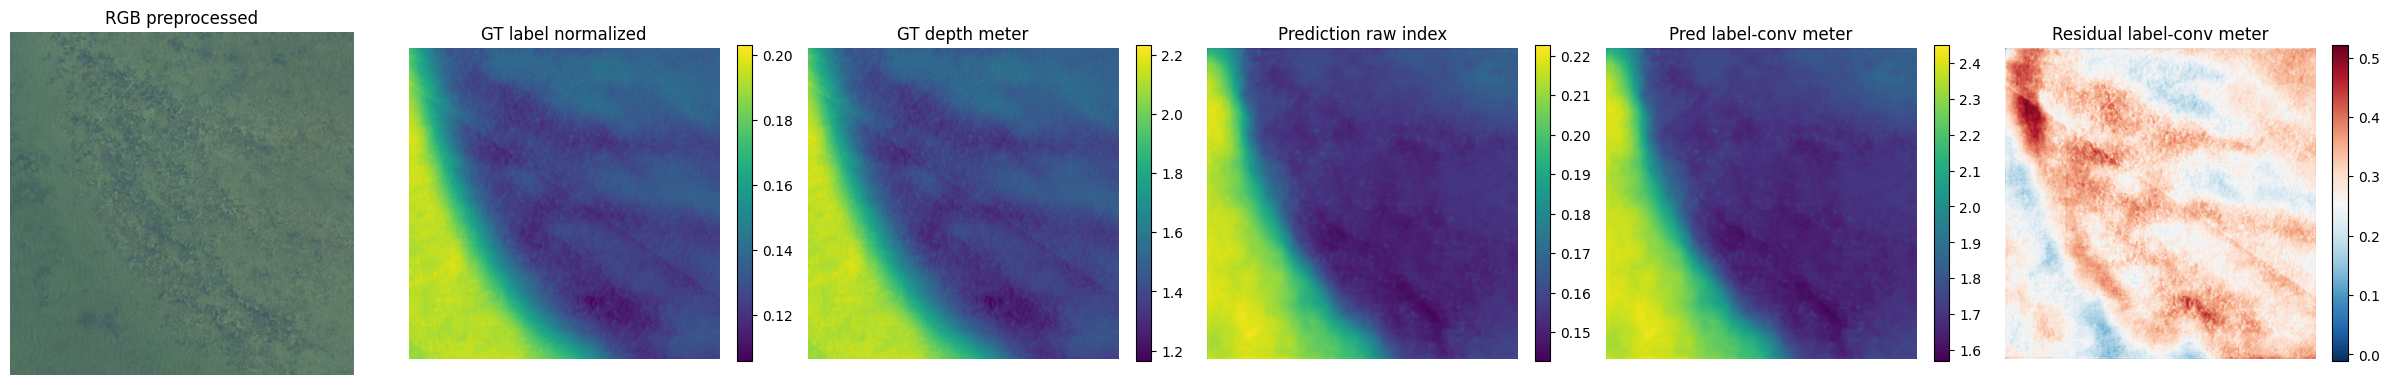

In [13]:
# ============================================================
# 9. Sample prediction visualization
# ============================================================

import matplotlib.pyplot as plt

@torch.no_grad()
def show_sample_prediction(model, loader, norm_param_depth=NORM_PARAM_DEPTH):
    model.eval()
    batch = next(iter(loader))
    x = batch["x"].to(DEVICE)
    y = batch["y"].to(DEVICE)
    mask = batch.get("mask", None)
    if mask is not None:
        mask = mask.to(DEVICE)

    with torch.amp.autocast("cuda", enabled=USE_AMP, dtype=AMP_DTYPE):
        pred = model(x)

    rgb = x[0].detach().cpu().numpy().transpose(1,2,0)
    label = y[0,0].detach().cpu().numpy()
    pred_raw = pred[0,0].detach().cpu().float().numpy()
    mask_np = mask[0,0].detach().cpu().numpy().astype(bool) if mask is not None else np.isfinite(label)

    label_plot = label.copy()
    label_plot[~mask_np] = np.nan

    pred_plot = pred_raw.copy()
    pred_plot[~mask_np] = np.nan

    label_m = label_norm_to_depth_m(label_plot, norm_param_depth)
    pred_m_label_conv = label_norm_to_depth_m(pred_plot, norm_param_depth)
    residual = pred_m_label_conv - label_m

    print("Label norm valid min/max:", float(np.nanmin(label_plot)), float(np.nanmax(label_plot)))
    print("Prediction raw min/max:", float(np.nanmin(pred_raw)), float(np.nanmax(pred_raw)))
    print("Prediction label-convention meter min/max:", float(np.nanmin(pred_m_label_conv)), float(np.nanmax(pred_m_label_conv)))

    fig, axes = plt.subplots(1, 6, figsize=(24, 4))
    axes[0].imshow(np.clip(rgb, 0, 1)); axes[0].set_title("RGB preprocessed")
    im1 = axes[1].imshow(label_plot); axes[1].set_title("GT label normalized"); plt.colorbar(im1, ax=axes[1], fraction=0.046)
    im2 = axes[2].imshow(label_m); axes[2].set_title("GT depth meter"); plt.colorbar(im2, ax=axes[2], fraction=0.046)
    im3 = axes[3].imshow(pred_raw); axes[3].set_title("Prediction raw index"); plt.colorbar(im3, ax=axes[3], fraction=0.046)
    im4 = axes[4].imshow(pred_m_label_conv); axes[4].set_title("Pred label-conv meter"); plt.colorbar(im4, ax=axes[4], fraction=0.046)
    im5 = axes[5].imshow(residual, cmap="RdBu_r"); axes[5].set_title("Residual label-conv meter"); plt.colorbar(im5, ax=axes[5], fraction=0.046)
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    out = FIG_DIR / "sample_prediction_debug.png"
    plt.savefig(out, dpi=200, bbox_inches="tight")
    print("Saved:", out)
    plt.show()

show_sample_prediction(model, val_loader)


## 10. UAV GeoTIFF tile-based inference

In [17]:
# ============================================================
# 10. UAV GeoTIFF inference
# ============================================================

import rasterio
from rasterio.windows import Window
from tqdm.auto import tqdm

RAW_DA_TIF = OUT_DIR / "da_v2_raw_prediction_normalized_index.tif"

def read_ortho_window(src, window):
    arr = src.read(window=window)
    arr = np.transpose(arr, (1,2,0))
    if arr.shape[2] >= 4:
        alpha = arr[:, :, 3]
        rgb = arr[:, :, :3]
        valid_mask = alpha > 0
    else:
        rgb = arr[:, :, :3]
        valid_mask = np.ones(arr.shape[:2], dtype=bool)
    return rgb, valid_mask

@torch.no_grad()
def infer_geotiff(model, ortho_tif, out_tif, tile=DA_INPUT_SIZE, overlap=112, device=DEVICE):
    model.eval()
    with rasterio.open(ortho_tif) as src:
        H, W = src.height, src.width
        profile = src.profile.copy()
        crs = src.crs
        transform = src.transform
        pred_accum = np.zeros((H, W), dtype=np.float32)
        weight_accum = np.zeros((H, W), dtype=np.float32)
        step = tile - overlap
        ys = list(range(0, H, step))
        xs = list(range(0, W, step))

        for y0 in tqdm(ys, desc="geotiff rows"):
            for x0 in xs:
                h = min(tile, H - y0)
                w = min(tile, W - x0)
                window = Window(x0, y0, w, h)
                rgb, valid_mask = read_ortho_window(src, window)
                # Use edge padding, not zero padding. Zero padding creates artificial black borders
                # that can bias Depth Anything predictions at edge tiles.
                if h < tile or w < tile:
                    pad_h = tile - h
                    pad_w = tile - w
                    rgb_pad = np.pad(rgb[:, :, :3], ((0, pad_h), (0, pad_w), (0, 0)), mode="edge")
                    mask_pad = np.pad(valid_mask, ((0, pad_h), (0, pad_w)), mode="constant", constant_values=False)
                else:
                    rgb_pad = rgb[:, :, :3]
                    mask_pad = valid_mask
                rgb_p = preprocess_rgb(rgb_pad, resize_to=None)
                x = torch.from_numpy(np.transpose(rgb_p, (2,0,1))).unsqueeze(0).float().to(device)
                with torch.amp.autocast("cuda", enabled=USE_AMP, dtype=AMP_DTYPE):
                    pred = model(x)
                pred_np = pred[0,0].detach().cpu().float().numpy()
                pred_crop = pred_np[:h, :w]
                valid_crop = mask_pad[:h, :w].astype(np.float32)
                pred_accum[y0:y0+h, x0:x0+w] += pred_crop * valid_crop
                weight_accum[y0:y0+h, x0:x0+w] += valid_crop

        nodata = -9999.0
        out = np.full((H, W), nodata, dtype=np.float32)
        valid = weight_accum > 0
        out[valid] = pred_accum[valid] / weight_accum[valid]
        profile.update(driver="GTiff", dtype="float32", count=1, nodata=nodata, compress="lzw", crs=crs, transform=transform)
        profile.pop("blockxsize", None)
        profile.pop("blockysize", None)
        profile.pop("tiled", None)
        profile.pop("interleave", None)
        with rasterio.open(out_tif, "w", **profile) as dst:
            dst.write(out, 1)
        print("Saved raw DA V2 prediction GeoTIFF:", out_tif)
        print("CRS preserved:", crs)
        valid_values = out[out != nodata]
        print("Output min/max excluding nodata:", float(np.nanmin(valid_values)), float(np.nanmax(valid_values)))
    return out_tif

RAW_DA_TIF = infer_geotiff(model, ORTHO_TIF, RAW_DA_TIF, tile=DA_INPUT_SIZE, overlap=112)


geotiff rows:   0%|          | 0/11 [00:00<?, ?it/s]

Saved raw DA V2 prediction GeoTIFF: /content/drive/MyDrive/MagicBathyNet_DA_V2_real_finetuning_v2/outputs/da_v2_raw_prediction_normalized_index.tif
CRS preserved: EPSG:32719
Output min/max excluding nodata: 0.0238037109375 0.4912109375


## 11. GPR sampling and metric evaluation

In [21]:
# ============================================================
# 11. GPR sampling and validation
# ============================================================

from pyproj import Transformer
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, LeaveOneOut

def read_gpr_excel(path):
    gpr = pd.read_excel(path)
    required = ["Latitude", "Longitude", "Depth [m]"]
    missing = [c for c in required if c not in gpr.columns]
    if missing:
        raise ValueError(f"Missing GPR columns: {missing}")
    gpr = gpr.dropna(subset=required).copy()
    print("GPR count:", len(gpr))
    display(gpr.head())
    return gpr

def sample_raster_at_gpr(raster_tif, gpr_df):
    with rasterio.open(raster_tif) as src:
        arr = src.read(1).astype(np.float32)
        nodata = src.nodata
        crs = src.crs
        H, W = src.height, src.width
        transformer = Transformer.from_crs("EPSG:4326", crs, always_xy=True)
        xs, ys = transformer.transform(gpr_df["Longitude"].to_numpy(dtype=float), gpr_df["Latitude"].to_numpy(dtype=float))
        rows, cols = rasterio.transform.rowcol(src.transform, xs, ys)
    out = gpr_df.copy()
    out["x_proj"] = xs
    out["y_proj"] = ys
    out["row"] = rows
    out["col"] = cols
    rows = np.asarray(rows)
    cols = np.asarray(cols)
    inside = (rows >= 0) & (rows < H) & (cols >= 0) & (cols < W)
    sampled = np.full(len(out), np.nan, dtype=np.float32)
    sampled[inside] = arr[rows[inside], cols[inside]]
    invalid = ~np.isfinite(sampled)
    if nodata is not None:
        invalid |= sampled == nodata
    out["pred_sample"] = sampled
    out["inside_raster"] = inside
    out["valid_sample"] = inside & (~invalid)
    print("Total GPR:", len(out))
    print("Outside raster:", int((~out["inside_raster"]).sum()))
    print("Invalid/nodata sample:", int((out["inside_raster"] & ~out["valid_sample"]).sum()))
    print("Valid sample:", int(out["valid_sample"].sum()))
    return out

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) < 2:
        return {"n": len(y_true), "Pearson R": np.nan, "Spearman R": np.nan, "MAE": np.nan, "RMSE": np.nan, "R²": np.nan, "Bias": np.nan}
    return {"n": len(y_true), "Pearson R": pearsonr(y_true, y_pred)[0], "Spearman R": spearmanr(y_true, y_pred)[0], "MAE": mean_absolute_error(y_true, y_pred), "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)), "R²": r2_score(y_true, y_pred), "Bias": np.mean(y_pred - y_true)}

gpr = read_gpr_excel(GPR_XLSX)
sampled_raw = sample_raster_at_gpr(RAW_DA_TIF, gpr)
valid_gpr = sampled_raw[sampled_raw["valid_sample"] == True].copy()
display(valid_gpr.head())


GPR count: 112


,Trace,Latitude,Longitude,Depth [m]
0,107,-67.828755,-67.226238,0.6275
1,95,-67.828787,-67.226274,0.3922
2,73,-67.828838,-67.226298,0.3660
3,47,-67.828889,-67.226299,0.3660
4,25,-67.828920,-67.226297,0.3660


Total GPR: 112
Outside raster: 0
Invalid/nodata sample: 3
Valid sample: 109


,Trace,Latitude,Longitude,Depth [m],x_proj,y_proj,row,col,pred_sample,inside_raster,valid_sample
0,107,-67.828755,-67.226238,0.6275,574690.904369,2.475157e+06,3603,590,0.087891,True,True
1,95,-67.828787,-67.226274,0.3922,574689.314333,2.475154e+06,3694,550,0.071045,True,True
2,73,-67.828838,-67.226298,0.3660,574688.127498,2.475148e+06,3837,519,0.066406,True,True
6,114,-67.828736,-67.226254,0.7059,574690.295835,2.475159e+06,3549,575,0.089844,True,True
7,127,-67.828689,-67.226288,0.8105,574689.021484,2.475164e+06,3414,542,0.113281,True,True


## 12. Cross-validation calibration and thesis-ready metrics

In [22]:
# ============================================================
# 12. Cross-validation calibration and thesis-ready metrics
# ============================================================

def normalize_01(v):
    v = np.asarray(v, dtype=float)
    return (v - np.nanmin(v)) / (np.nanmax(v) - np.nanmin(v) + 1e-8)

def fit_linear_calibration(x, y):
    x = np.asarray(x, dtype=float).reshape(-1, 1)
    y = np.asarray(y, dtype=float)
    m = LinearRegression()
    m.fit(x, y)
    return m

def cv_linear_calibration(df, pred_col="pred_sample", target_col="Depth [m]", mode="loocv", n_splits=5):
    d = df.dropna(subset=[pred_col, target_col]).copy()
    x = d[pred_col].to_numpy(dtype=float)
    y = d[target_col].to_numpy(dtype=float)
    y_cv = np.full(len(d), np.nan)
    splitter = LeaveOneOut() if mode == "loocv" else KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    coefs, intercepts = [], []
    for tr_idx, te_idx in splitter.split(x):
        m = fit_linear_calibration(x[tr_idx], y[tr_idx])
        y_cv[te_idx] = m.predict(x[te_idx].reshape(-1,1))
        coefs.append(float(m.coef_[0]))
        intercepts.append(float(m.intercept_))
    d["pred_cv_calibrated_m"] = y_cv
    d["cv_residual_m"] = d["pred_cv_calibrated_m"] - d[target_col]
    met = compute_metrics(y, y_cv)
    met["coef_mean"] = float(np.mean(coefs))
    met["coef_std"] = float(np.std(coefs))
    met["intercept_mean"] = float(np.mean(intercepts))
    met["intercept_std"] = float(np.std(intercepts))
    return d, met

raw = valid_gpr["pred_sample"].to_numpy(dtype=float)
obs = valid_gpr["Depth [m]"].to_numpy(dtype=float)

raw_index_as_meter = raw
raw_scaled = label_norm_to_depth_m(raw, NORM_PARAM_DEPTH)
inv01_scaled = label_norm_to_depth_m(1 - normalize_01(raw), NORM_PARAM_DEPTH)
cal_raw_model = fit_linear_calibration(raw, obs)
cal_raw = cal_raw_model.predict(raw.reshape(-1,1))

rows = []
def add_case(name, pred, eval_type):
    m = compute_metrics(obs, pred)
    rows.append({"Evaluation type": eval_type, "Case": name, **m})

add_case("Raw output interpreted directly as depth — diagnostic only", raw_index_as_meter, "Diagnostic / in-sample")
add_case("Raw output converted using training label convention", raw_scaled, "Diagnostic / in-sample")
add_case("Inverse output converted using training label convention", inv01_scaled, "Diagnostic / in-sample")
add_case("Raw output with linear GPR calibration — in-sample", cal_raw, "In-sample calibration")

cv_loocv_df, loocv_met = cv_linear_calibration(valid_gpr, mode="loocv")
cv_5fold_df, kfold_met = cv_linear_calibration(valid_gpr, mode="kfold", n_splits=5)

rows.append({"Evaluation type": "Cross-validated", "Case": "Raw output with linear GPR calibration — leave-one-out cross-validation", **loocv_met})
rows.append({"Evaluation type": "Cross-validated", "Case": "Raw output with linear GPR calibration — 5-fold cross-validation", **kfold_met})

metrics_table = pd.DataFrame(rows)
display(metrics_table)

metrics_table.to_csv(TABLE_DIR / "da_v2_metrics_thesis_ready.csv", index=False)
cv_loocv_df.to_csv(TABLE_DIR / "da_v2_loocv_predictions.csv", index=False)
cv_5fold_df.to_csv(TABLE_DIR / "da_v2_5fold_predictions.csv", index=False)

print("Raw calibration equation:")
print(f"depth_m = {float(cal_raw_model.coef_[0]):.6f} * raw + {float(cal_raw_model.intercept_):.6f}")


,Evaluation type,Case,n,Pearson R,Spearman R,MAE,RMSE,R²,Bias,coef_mean,coef_std,intercept_mean,intercept_std
0,Diagnostic / in-sample,Raw output interpreted directly as depth — dia...,109,0.903013,0.901654,1.064123,1.220677,-2.117546,-1.064123e+00,NaN,NaN,NaN,NaN
1,Diagnostic / in-sample,Raw output converted using training label conv...,109,0.903013,0.901654,1.300580,1.436482,-3.317298,1.300580e+00,NaN,NaN,NaN,NaN
2,Diagnostic / in-sample,Inverse output converted using training label ...,109,-0.903013,-0.901654,4.967581,6.019162,-74.802514,4.749530e+00,NaN,NaN,NaN,NaN
3,In-sample calibration,Raw output with linear GPR calibration — in-sa...,109,0.903013,0.901654,0.223925,0.297011,0.815432,-2.526012e-16,NaN,NaN,NaN,NaN
4,Cross-validated,Raw output with linear GPR calibration — leave...,109,0.898925,0.898949,0.228319,0.302898,0.808043,-1.302564e-04,5.935505,0.027995,-0.102979,0.005644
5,Cross-validated,Raw output with linear GPR calibration — 5-fol...,109,0.899512,0.899204,0.226522,0.302090,0.809066,1.518049e-03,5.939734,0.084439,-0.103674,0.021633


Raw calibration equation:
depth_m = 5.935466 * raw + -0.102968


## 13. GPR-calibrated GeoTIFF and negative depth handling

In [23]:
# ============================================================
# 13. GPR-calibrated GeoTIFF and negative depth handling
# ============================================================

CAL_DA_TIF = OUT_DIR / "da_v2_gpr_calibrated_depth_m.tif"
CAL_DA_TIF_NONNEG = OUT_DIR / "da_v2_gpr_calibrated_depth_m_nonnegative_for_figures.tif"

def write_calibrated_geotiff(raw_tif, out_tif, calibration_model):
    with rasterio.open(raw_tif) as src:
        raw_arr = src.read(1).astype(np.float32)
        profile = src.profile.copy()
        nodata = src.nodata
    flat = raw_arr.reshape(-1)
    valid = np.isfinite(flat)
    if nodata is not None:
        valid &= flat != nodata
    out_flat = np.full(flat.shape, np.nan, dtype=np.float32)
    out_flat[valid] = calibration_model.predict(flat[valid].reshape(-1,1)).astype(np.float32)
    out_arr = out_flat.reshape(raw_arr.shape)
    out_nodata = -9999.0
    out_write = out_arr.copy()
    out_write[~np.isfinite(out_write)] = out_nodata
    profile.update(dtype="float32", count=1, nodata=out_nodata, compress="lzw")
    profile.pop("blockxsize", None)
    profile.pop("blockysize", None)
    profile.pop("tiled", None)
    profile.pop("interleave", None)
    with rasterio.open(out_tif, "w", **profile) as dst:
        dst.write(out_write, 1)
    valid_vals = out_write[out_write != out_nodata]
    print("Saved:", out_tif)
    print("Calibrated min/max excluding nodata:", float(np.nanmin(valid_vals)), float(np.nanmax(valid_vals)))
    return out_tif

def create_nonnegative_raster(cal_tif, out_tif):
    with rasterio.open(cal_tif) as src:
        arr = src.read(1).astype(np.float32)
        profile = src.profile.copy()
        nodata = src.nodata if src.nodata is not None else -9999.0
    out = arr.copy()
    out[~np.isfinite(out)] = nodata
    out[out < 0] = nodata
    profile.update(dtype="float32", nodata=nodata, compress="lzw")
    profile.pop("blockxsize", None)
    profile.pop("blockysize", None)
    profile.pop("tiled", None)
    profile.pop("interleave", None)
    with rasterio.open(out_tif, "w", **profile) as dst:
        dst.write(out.astype(np.float32), 1)
    valid = out[out != nodata]
    print("Saved non-negative visualization raster:", out_tif)
    print("Non-negative min/max:", float(np.nanmin(valid)), float(np.nanmax(valid)))
    return out_tif

CAL_DA_TIF = write_calibrated_geotiff(RAW_DA_TIF, CAL_DA_TIF, cal_raw_model)
CAL_DA_TIF_NONNEG = create_nonnegative_raster(CAL_DA_TIF, CAL_DA_TIF_NONNEG)

print("NOTE: Non-negative raster is for visualization only. Metrics are not computed after masking negative values.")


Saved: /content/drive/MyDrive/MagicBathyNet_DA_V2_real_finetuning_v2/outputs/da_v2_gpr_calibrated_depth_m.tif
Calibrated min/max excluding nodata: 0.03831794485449791 2.8125977516174316
Saved non-negative visualization raster: /content/drive/MyDrive/MagicBathyNet_DA_V2_real_finetuning_v2/outputs/da_v2_gpr_calibrated_depth_m_nonnegative_for_figures.tif
Non-negative min/max: 0.03831794485449791 2.8125977516174316
NOTE: Non-negative raster is for visualization only. Metrics are not computed after masking negative values.


## 14. Academic maps and plots

Saved: /content/drive/MyDrive/MagicBathyNet_DA_V2_real_finetuning_v2/figures/da_v2_raw_prediction_map.png


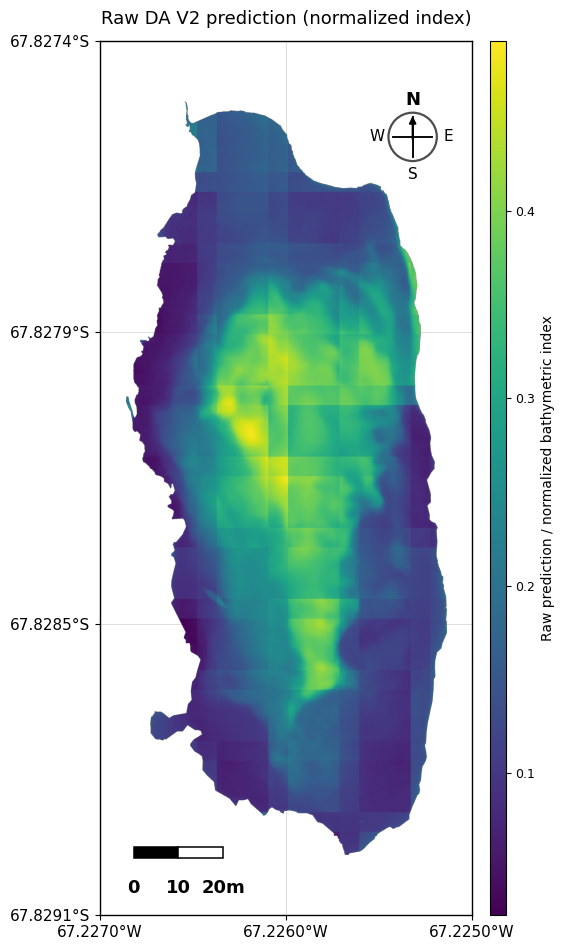

Saved: /content/drive/MyDrive/MagicBathyNet_DA_V2_real_finetuning_v2/figures/da_v2_raw_prediction_with_gpr.png


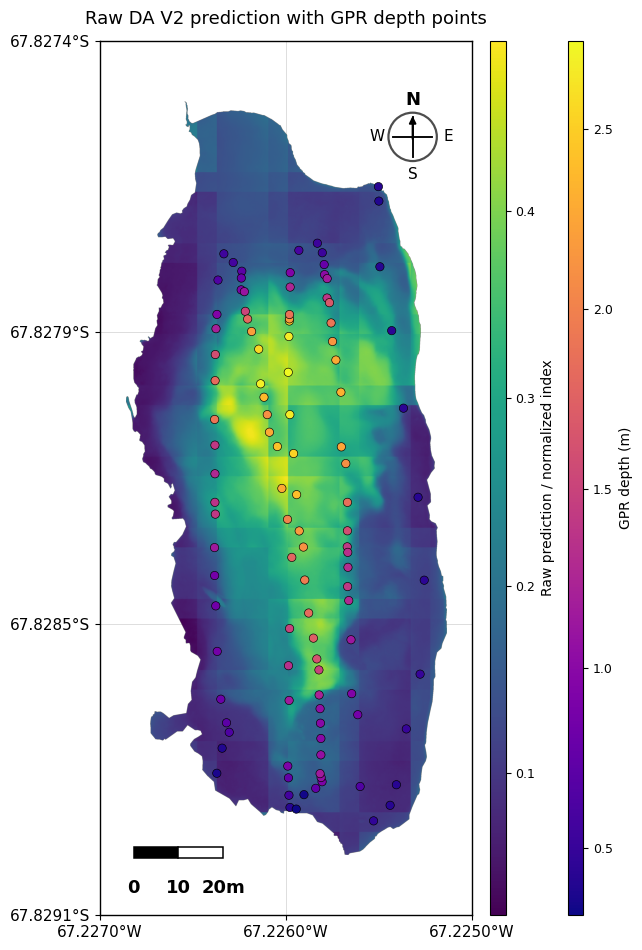

Saved: /content/drive/MyDrive/MagicBathyNet_DA_V2_real_finetuning_v2/figures/da_v2_gpr_calibrated_bathymetry_map.png


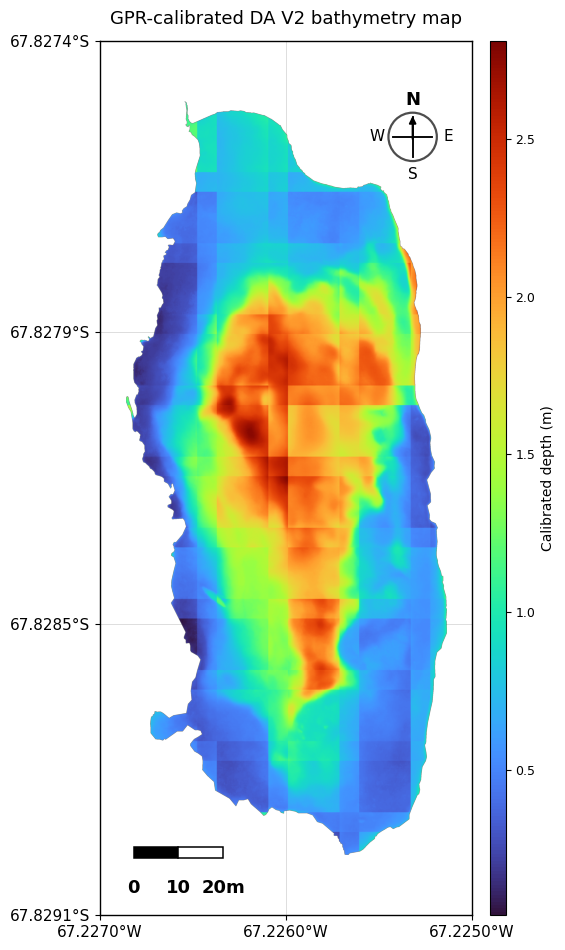

In [24]:
# ============================================================
# 14A. Academic maps
# ============================================================

from matplotlib.patches import Rectangle, Circle
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pyproj import Transformer

def format_lon(lon, decimals=4):
    return f"{abs(lon):.{decimals}f}°W" if lon < 0 else f"{abs(lon):.{decimals}f}°E"

def format_lat(lat, decimals=4):
    return f"{abs(lat):.{decimals}f}°S" if lat < 0 else f"{abs(lat):.{decimals}f}°N"

def padded_bounds(bounds, pad_frac=0.08):
    w = bounds.right - bounds.left
    h = bounds.top - bounds.bottom
    return {"left": bounds.left-w*pad_frac, "right": bounds.right+w*pad_frac, "bottom": bounds.bottom-h*pad_frac, "top": bounds.top+h*pad_frac}

def set_sw_ticks(ax, raster_crs, pb, nx=3, ny=4, decimals=4):
    transformer = Transformer.from_crs(raster_crs, "EPSG:4326", always_xy=True)
    xticks = np.linspace(pb["left"], pb["right"], nx)
    yticks = np.linspace(pb["bottom"], pb["top"], ny)
    ax.set_xticks(xticks); ax.set_yticks(yticks)
    ymid = 0.5*(pb["bottom"]+pb["top"])
    xmid = 0.5*(pb["left"]+pb["right"])
    ax.set_xticklabels([format_lon(transformer.transform(x, ymid)[0], decimals) for x in xticks], fontsize=11)
    ax.set_yticklabels([format_lat(transformer.transform(xmid, y)[1], decimals) for y in yticks], fontsize=11)
    ax.set_xlabel(""); ax.set_ylabel("")

def add_compass_rose(ax, bbox=(0.715, 0.765, 0.25, 0.25)):
    iax = ax.inset_axes(bbox, transform=ax.transAxes)
    iax.set_aspect("equal"); iax.set_xlim(0,1); iax.set_ylim(0,1); iax.axis("off")
    r = 0.26
    iax.add_patch(Circle((0.5,0.5), r, fill=False, lw=1.6, ec="0.30"))
    iax.plot([0.5,0.5],[0.5-r*0.82,0.5+r*0.82], color="black", lw=1.35)
    iax.plot([0.5-r*0.82,0.5+r*0.82],[0.5,0.5], color="black", lw=1.35)
    iax.annotate("", xy=(0.5,0.5+r*0.98), xytext=(0.5,0.5-r*0.20), arrowprops=dict(arrowstyle="-|>", lw=1.45, color="black"))
    iax.text(0.5,0.90,"N", ha="center", va="center", fontsize=13, fontweight="bold")
    iax.text(0.88,0.5,"E", ha="center", va="center", fontsize=11)
    iax.text(0.5,0.10,"S", ha="center", va="center", fontsize=11)
    iax.text(0.12,0.5,"W", ha="center", va="center", fontsize=11)

def add_scale_bar(ax, pb, length_m=20, location=(0.09, 0.065)):
    x0 = pb["left"] + location[0]*(pb["right"]-pb["left"])
    y0 = pb["bottom"] + location[1]*(pb["top"]-pb["bottom"])
    h = (pb["top"]-pb["bottom"]) * 0.013
    half = length_m / 2
    ax.add_patch(Rectangle((x0-length_m*0.18, y0-h*3.8), length_m*1.42, h*6.4, facecolor="white", edgecolor="none", alpha=0.88, zorder=18))
    ax.add_patch(Rectangle((x0,y0), half, h, facecolor="black", edgecolor="black", lw=1.1, zorder=19))
    ax.add_patch(Rectangle((x0+half,y0), half, h, facecolor="white", edgecolor="black", lw=1.1, zorder=19))
    label_y = y0 - h*1.85
    for xx, lab in [(x0,"0"), (x0+half,"10"), (x0+length_m,"20m")]:
        ax.text(xx, label_y, lab, ha="center", va="top", fontsize=13, fontweight="bold", color="black", zorder=21, clip_on=False)

def read_raster_for_plot(tif):
    with rasterio.open(tif) as src:
        arr = src.read(1).astype(np.float32)
        nodata = src.nodata
        bounds = src.bounds
        crs = src.crs
    if nodata is not None:
        arr[arr == nodata] = np.nan
    arr[~np.isfinite(arr)] = np.nan
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    return arr, bounds, crs, extent

def plot_map(tif, title, cbar_label, out_png, cmap="viridis", gpr_points=None, gpr_cbar=False):
    arr, bounds, crs, extent = read_raster_for_plot(tif)
    pb = padded_bounds(bounds)
    fig, ax = plt.subplots(figsize=(7.6, 9.6))
    im = ax.imshow(arr, extent=extent, origin="upper", cmap=cmap, zorder=2)
    sc = None
    if gpr_points is not None:
        sc = ax.scatter(gpr_points["x_proj"], gpr_points["y_proj"], c=gpr_points["Depth [m]"], cmap="plasma", s=36, edgecolors="black", linewidths=0.45, zorder=5)
    ax.set_xlim(pb["left"], pb["right"]); ax.set_ylim(pb["bottom"], pb["top"])
    set_sw_ticks(ax, crs, pb)
    ax.grid(True, color="gray", alpha=0.30, linewidth=0.6, zorder=1)
    add_compass_rose(ax); add_scale_bar(ax, pb)
    ax.set_title(title, fontsize=13, pad=12)
    divider = make_axes_locatable(ax)
    cax1 = divider.append_axes("right", size="4.2%", pad=0.18)
    cbar1 = fig.colorbar(im, cax=cax1)
    cbar1.set_label(cbar_label, fontsize=10)
    cbar1.ax.tick_params(labelsize=9)
    if sc is not None and gpr_cbar:
        cax2 = divider.append_axes("right", size="4.2%", pad=0.62)
        cbar2 = fig.colorbar(sc, cax=cax2)
        cbar2.set_label("GPR depth (m)", fontsize=10)
        cbar2.ax.tick_params(labelsize=9)
    for s in ax.spines.values():
        s.set_linewidth(1.0)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")
    print("Saved:", out_png)
    plt.show()

plot_map(RAW_DA_TIF, "Raw DA V2 prediction (normalized index)", "Raw prediction / normalized bathymetric index", FIG_DIR / "da_v2_raw_prediction_map.png", cmap="viridis")
plot_map(RAW_DA_TIF, "Raw DA V2 prediction with GPR depth points", "Raw prediction / normalized index", FIG_DIR / "da_v2_raw_prediction_with_gpr.png", cmap="viridis", gpr_points=valid_gpr, gpr_cbar=True)
plot_map(CAL_DA_TIF_NONNEG, "GPR-calibrated DA V2 bathymetry map", "Calibrated depth (m)", FIG_DIR / "da_v2_gpr_calibrated_bathymetry_map.png", cmap="turbo")


Saved: /content/drive/MyDrive/MagicBathyNet_DA_V2_real_finetuning_v2/figures/da_v2_loocv_observed_vs_predicted.png


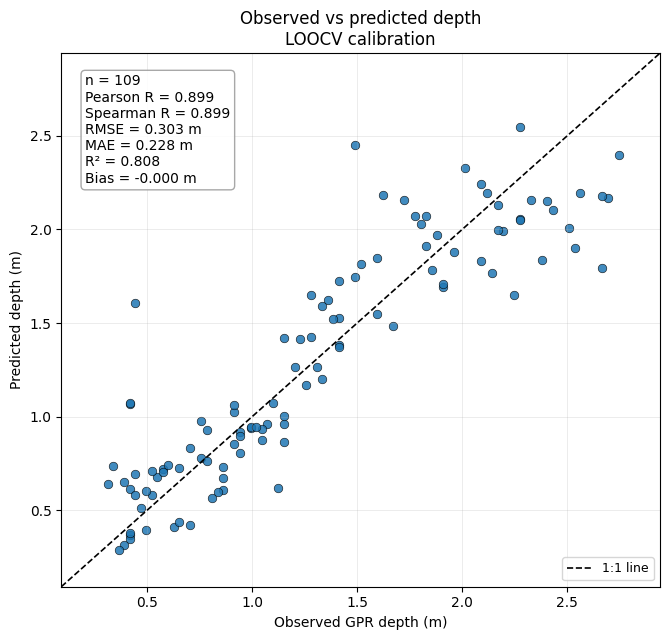

Saved: /content/drive/MyDrive/MagicBathyNet_DA_V2_real_finetuning_v2/figures/da_v2_residual_histogram_boxplot_loocv.png


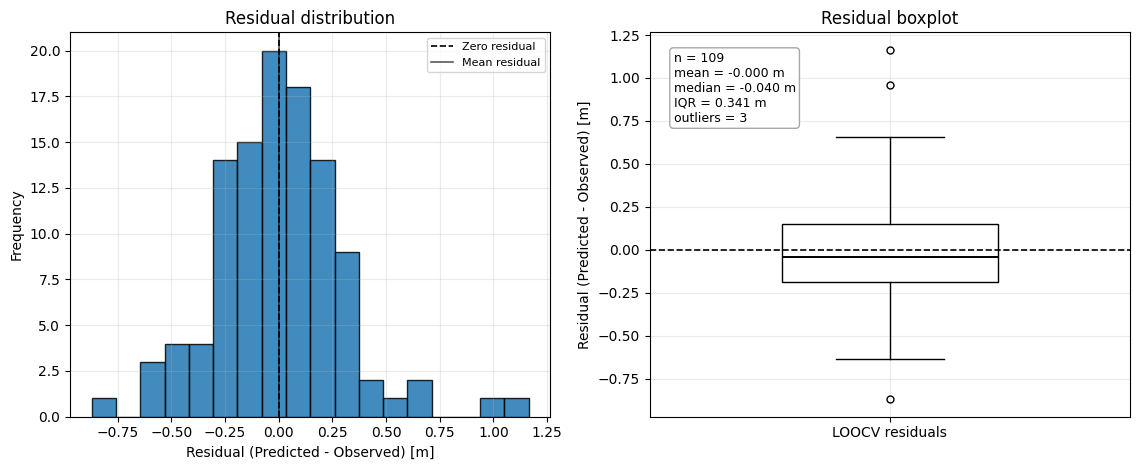

Saved: /content/drive/MyDrive/MagicBathyNet_DA_V2_real_finetuning_v2/figures/da_v2_residual_map_loocv.png


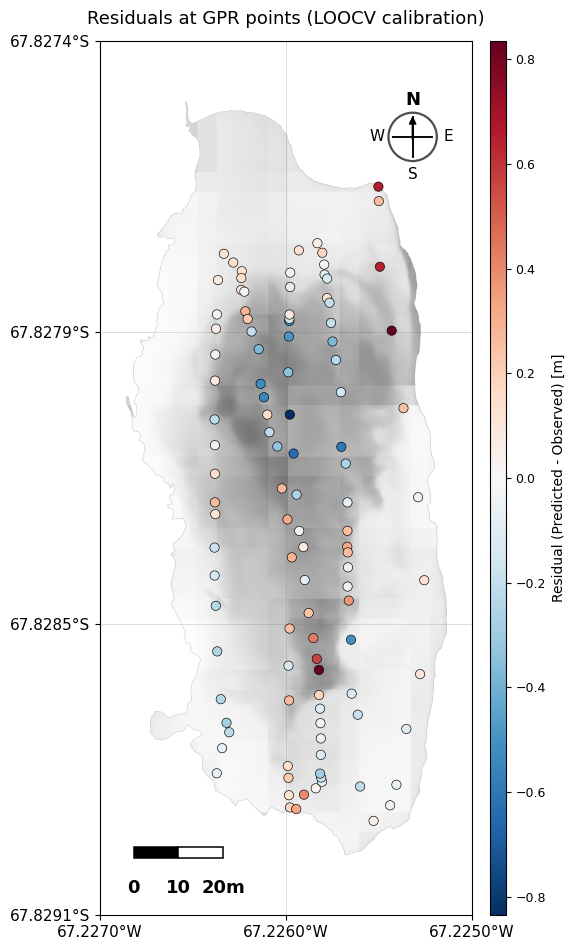

In [25]:
# ============================================================
# 14B. Scatter, residual histogram/boxplot, residual map
# ============================================================

def plot_loocv_scatter(df, out_png):
    d = df.dropna(subset=["Depth [m]", "pred_cv_calibrated_m"]).copy()
    y = d["Depth [m]"].to_numpy(float)
    p = d["pred_cv_calibrated_m"].to_numpy(float)
    met = compute_metrics(y, p)
    mn = np.nanmin([y.min(), p.min()])
    mx = np.nanmax([y.max(), p.max()])
    pad = (mx - mn) * 0.08
    fig, ax = plt.subplots(figsize=(6.8,6.5))
    ax.scatter(y, p, s=38, edgecolors="black", linewidths=0.45, alpha=0.85)
    ax.plot([mn-pad, mx+pad], [mn-pad, mx+pad], "--", color="black", lw=1.2, label="1:1 line")
    ax.set_xlim(mn-pad, mx+pad); ax.set_ylim(mn-pad, mx+pad)
    ax.set_xlabel("Observed GPR depth (m)")
    ax.set_ylabel("Predicted depth (m)")
    ax.set_title("Observed vs predicted depth\nLOOCV calibration")
    txt = "\n".join([f"n = {met['n']}", f"Pearson R = {met['Pearson R']:.3f}", f"Spearman R = {met['Spearman R']:.3f}", f"RMSE = {met['RMSE']:.3f} m", f"MAE = {met['MAE']:.3f} m", f"R² = {met['R²']:.3f}", f"Bias = {met['Bias']:.3f} m"])
    ax.text(0.04,0.96,txt, transform=ax.transAxes, va="top", ha="left", fontsize=10, bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.6", alpha=0.85))
    ax.grid(True, alpha=0.28, linewidth=0.6)
    ax.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")
    print("Saved:", out_png)
    plt.show()

plot_loocv_scatter(cv_loocv_df, FIG_DIR / "da_v2_loocv_observed_vs_predicted.png")

residual_df = cv_loocv_df.copy()
residual_df["residual_m"] = residual_df["pred_cv_calibrated_m"] - residual_df["Depth [m]"]
residual_df["abs_residual_m"] = residual_df["residual_m"].abs()

def plot_residual_hist_box(df, out_png):
    vals = df["residual_m"].to_numpy(float)
    vals = vals[np.isfinite(vals)]
    q1, q3 = np.percentile(vals, [25, 75])
    iqr = q3-q1
    outlier_count = int(((vals < q1-1.5*iqr) | (vals > q3+1.5*iqr)).sum())
    fig, axes = plt.subplots(1,2, figsize=(11.5,4.8))
    axes[0].hist(vals, bins=18, edgecolor="black", alpha=0.85)
    axes[0].axvline(0, linestyle="--", color="black", lw=1.2, label="Zero residual")
    axes[0].axvline(np.mean(vals), linestyle="-", color="black", lw=1.2, alpha=0.65, label="Mean residual")
    axes[0].set_title("Residual distribution")
    axes[0].set_xlabel("Residual (Predicted - Observed) [m]")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(True, alpha=0.25)
    axes[0].legend(fontsize=8)
    axes[1].boxplot(vals, vert=True, patch_artist=True, widths=0.45, boxprops=dict(facecolor="white", color="black"), medianprops=dict(color="black", linewidth=1.4), flierprops=dict(marker="o", markerfacecolor="none", markeredgecolor="black", markersize=5))
    axes[1].axhline(0, linestyle="--", color="black", lw=1.2)
    axes[1].set_title("Residual boxplot")
    axes[1].set_ylabel("Residual (Predicted - Observed) [m]")
    axes[1].set_xticks([1]); axes[1].set_xticklabels(["LOOCV residuals"])
    axes[1].grid(True, alpha=0.25)
    info = f"n = {len(vals)}\nmean = {np.mean(vals):.3f} m\nmedian = {np.median(vals):.3f} m\nIQR = {iqr:.3f} m\noutliers = {outlier_count}"
    axes[1].text(0.05,0.95,info, transform=axes[1].transAxes, va="top", fontsize=9, bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.6", alpha=0.85))
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")
    print("Saved:", out_png)
    plt.show()

plot_residual_hist_box(residual_df, FIG_DIR / "da_v2_residual_histogram_boxplot_loocv.png")

def plot_residual_map(base_tif, df, out_png):
    arr, bounds, crs, extent = read_raster_for_plot(base_tif)
    pb = padded_bounds(bounds)
    d = df.dropna(subset=["x_proj", "y_proj", "residual_m"]).copy()
    vals = d["residual_m"].to_numpy(float)
    vmax = np.nanpercentile(np.abs(vals), 98)
    if not np.isfinite(vmax) or vmax == 0:
        vmax = np.nanmax(np.abs(vals))
    fig, ax = plt.subplots(figsize=(7.6,9.6))
    ax.imshow(arr, extent=extent, origin="upper", cmap="Greys", alpha=0.55, zorder=1)
    sc = ax.scatter(d["x_proj"], d["y_proj"], c=d["residual_m"], cmap="RdBu_r", vmin=-vmax, vmax=vmax, s=45, edgecolors="black", linewidths=0.45, zorder=5)
    ax.set_xlim(pb["left"], pb["right"]); ax.set_ylim(pb["bottom"], pb["top"])
    set_sw_ticks(ax, crs, pb)
    ax.grid(True, color="gray", alpha=0.30, linewidth=0.6, zorder=0)
    add_compass_rose(ax); add_scale_bar(ax, pb)
    ax.set_title("Residuals at GPR points (LOOCV calibration)", fontsize=13, pad=12)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4.2%", pad=0.18)
    cbar = fig.colorbar(sc, cax=cax)
    cbar.set_label("Residual (Predicted - Observed) [m]", fontsize=10)
    cbar.ax.tick_params(labelsize=9)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")
    print("Saved:", out_png)
    plt.show()

plot_residual_map(CAL_DA_TIF_NONNEG, residual_df, FIG_DIR / "da_v2_residual_map_loocv.png")
residual_df.to_csv(TABLE_DIR / "da_v2_loocv_residuals_all_points.csv", index=False)


## 15. Final interpretation cell

In [26]:
# ============================================================
# 15. Final interpretation
# ============================================================

def final_interpretation(model, param_info, metrics_table):
    da_trainable = len(param_info["da_trainable_names"]) > 0

    print("========== FINAL TECHNICAL INTERPRETATION ==========")

    if TRAIN_MODE == "frozen":
        print("Model mode: Frozen DA V2 backbone + trainable bathymetry head.")
        print("Decision: This is NOT Depth Anything V2 fine-tuning.")
        print("Safe thesis wording: Depth Anything V2-based feature extraction with a trainable bathymetry head.")
    elif da_trainable:
        print(f"Model mode: {TRAIN_MODE}")
        print("Decision: DA V2 backbone has trainable parameters.")
        print("Safe thesis wording: Depth Anything V2 partial/full fine-tuning, provided gradient and weight-update checks passed.")
    else:
        print("HATALI/RISK: DA V2 backbone is not trainable despite requested mode.")
        print("This run cannot be described as Depth Anything V2 fine-tuning.")

    print("\nArchitecture limitation:")
    print("- Current fast architecture adapts the final DA V2 depth-like output with a small bathymetry head.")
    print("- It does update DA V2 if partial/full mode passes gradient and weight-change checks.")
    print("- However, it is not equivalent to a richer regression head attached to intermediate DPT/ViT feature maps.")
    print("- Phrase claims accordingly: partial DA V2 fine-tuning of final-output adaptation, not full feature-head redesign.")

    print("\nOutput interpretation:")
    print("- Raw model output is treated as normalized/index output.")
    print("- It is not physical depth in meters unless converted by label convention or calibrated with GPR.")
    print("- Final metric reliability should be based on LOOCV / 5-fold CV, not only in-sample calibration.")

    print("\nMetric table:")
    display(metrics_table)

final_interpretation(model, param_info, metrics_table)


========== FINAL TECHNICAL INTERPRETATION ==========
Model mode: partial
Decision: DA V2 backbone has trainable parameters.
Safe thesis wording: Depth Anything V2 partial/full fine-tuning, provided gradient and weight-update checks passed.

Architecture limitation:
- Current fast architecture adapts the final DA V2 depth-like output with a small bathymetry head.
- It does update DA V2 if partial/full mode passes gradient and weight-change checks.
- However, it is not equivalent to a richer regression head attached to intermediate DPT/ViT feature maps.
- Phrase claims accordingly: partial DA V2 fine-tuning of final-output adaptation, not full feature-head redesign.

Output interpretation:
- Raw model output is treated as normalized/index output.
- It is not physical depth in meters unless converted by label convention or calibrated with GPR.
- Final metric reliability should be based on LOOCV / 5-fold CV, not only in-sample calibration.

Metric table:


,Evaluation type,Case,n,Pearson R,Spearman R,MAE,RMSE,R²,Bias,coef_mean,coef_std,intercept_mean,intercept_std
0,Diagnostic / in-sample,Raw output interpreted directly as depth — dia...,109,0.903013,0.901654,1.064123,1.220677,-2.117546,-1.064123e+00,NaN,NaN,NaN,NaN
1,Diagnostic / in-sample,Raw output converted using training label conv...,109,0.903013,0.901654,1.300580,1.436482,-3.317298,1.300580e+00,NaN,NaN,NaN,NaN
2,Diagnostic / in-sample,Inverse output converted using training label ...,109,-0.903013,-0.901654,4.967581,6.019162,-74.802514,4.749530e+00,NaN,NaN,NaN,NaN
3,In-sample calibration,Raw output with linear GPR calibration — in-sa...,109,0.903013,0.901654,0.223925,0.297011,0.815432,-2.526012e-16,NaN,NaN,NaN,NaN
4,Cross-validated,Raw output with linear GPR calibration — leave...,109,0.898925,0.898949,0.228319,0.302898,0.808043,-1.302564e-04,5.935505,0.027995,-0.102979,0.005644
5,Cross-validated,Raw output with linear GPR calibration — 5-fol...,109,0.899512,0.899204,0.226522,0.302090,0.809066,1.518049e-03,5.939734,0.084439,-0.103674,0.021633
